#**El** **objetivo del proyecto**
Predecir si un paciente tiene diabetes o no basándonos en sus datos médicos.
La columna Outcome es nuestra variable objetivo:

0 = no tiene diabetes
1 = sí tiene diabetes

Todo lo demás (glucosa, presión, edad...) son las pistas que el modelo usará para predecir.

In [2]:
from google.colab import files
uploaded = files.upload()

Saving diabetes.csv to diabetes.csv


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
df = pd.read_csv('diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
df.shape

(768, 9)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [7]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [8]:
columnas_con_ceros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

df[columnas_con_ceros] = df[columnas_con_ceros].replace(0, np.nan)

In [9]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [10]:
df[columnas_con_ceros] = df[columnas_con_ceros].fillna(df[columnas_con_ceros].median())

In [11]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0



# 📊 Visualización de Datos


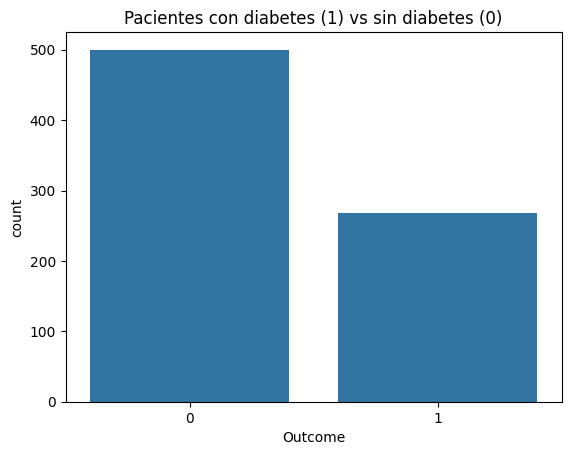

In [12]:
sns.countplot(x='Outcome', data=df)
plt.title('Pacientes con diabetes (1) vs sin diabetes (0)')
plt.show()

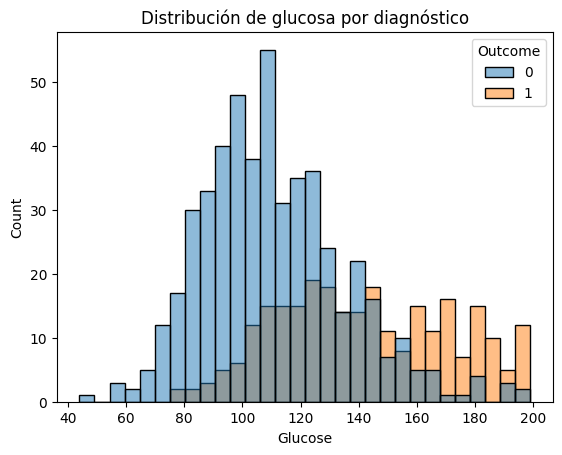

In [13]:
sns.histplot(data=df, x='Glucose', hue='Outcome', bins=30)
plt.title('Distribución de glucosa por diagnóstico')
plt.show()

Lado izquierdo (glucosa baja, 40-120):
Las barras son casi todas azules — la mayoría de pacientes sin diabetes tienen glucosa baja o normal
Lado derecho (glucosa alta, 140-200):
Empieza a aparecer mucho naranja — los pacientes con diabetes se concentran aquí

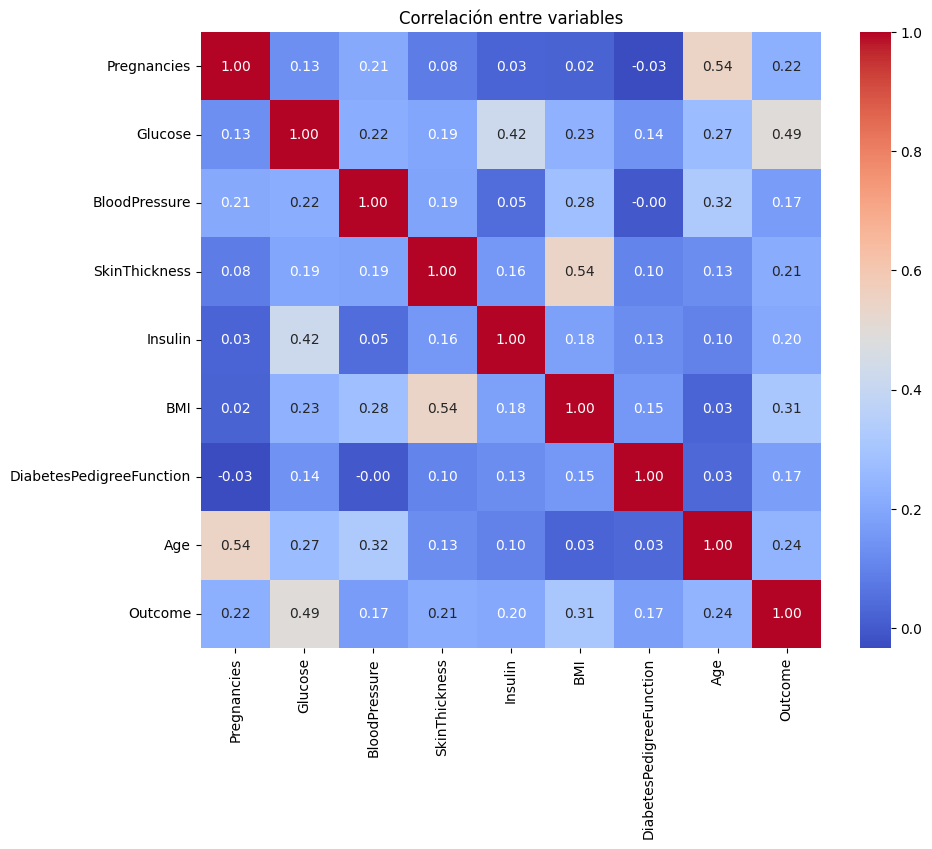

In [14]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlación entre variables')
plt.show()

In [15]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Dividir datos de entrenamiento y prueba

In [18]:
from sklearn.ensemble import RandomForestClassifier

modelo = RandomForestClassifier(n_estimators=100, random_state=42)
modelo.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [19]:
predicciones = modelo.predict(X_test)

In [20]:
from sklearn.metrics import accuracy_score, classification_report

print('Precisión:', accuracy_score(y_test, predicciones))
print(classification_report(y_test, predicciones))

Precisión: 0.7467532467532467
              precision    recall  f1-score   support

           0       0.81      0.79      0.80        99
           1       0.64      0.67      0.65        55

    accuracy                           0.75       154
   macro avg       0.73      0.73      0.73       154
weighted avg       0.75      0.75      0.75       154



In [21]:
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

In [22]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [25]:
modelos = {

    'SVM':           SVC(random_state=42),
    'Regresión Log': LogisticRegression(random_state=42),
    'KNN':           KNeighborsClassifier()
}

for nombre, modelo in modelos.items():
    modelo.fit(X_train_scaled, y_train)
    pred = modelo.predict(X_test_scaled)
    precision = accuracy_score(y_test, pred)
    print(f'{nombre}: {precision:.2%}')

SVM: 74.68%
Regresión Log: 75.32%
KNN: 72.08%


In [27]:
modelos = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM':           SVC(random_state=42),
    'Regresión Log': LogisticRegression(random_state=42),
    'KNN':           KNeighborsClassifier()
}

for nombre, modelo in modelos.items():
    modelo.fit(X_train_scaled, y_train)
    pred = modelo.predict(X_test_scaled)
    precision = accuracy_score(y_test, pred)
    print(f'{nombre}: {precision:.2%}')

Random Forest: 73.38%
SVM: 74.68%
Regresión Log: 75.32%
KNN: 72.08%


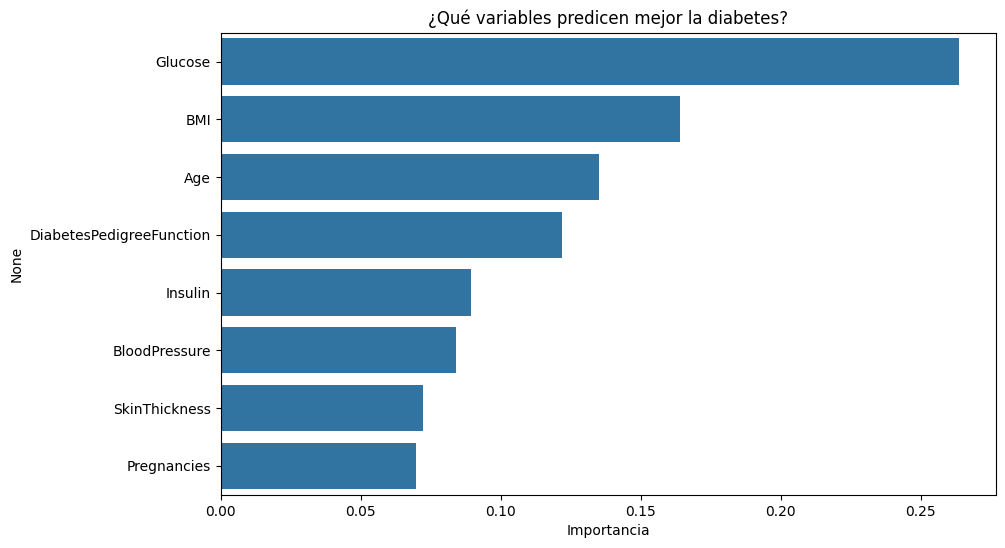

In [28]:
from sklearn.ensemble import RandomForestClassifier

modelo_rf = RandomForestClassifier(n_estimators=100, random_state=42)
modelo_rf.fit(X_train_scaled, y_train)

importancias = modelo_rf.feature_importances_
caracteristicas = X.columns

plt.figure(figsize=(10,6))
sns.barplot(x=importancias, y=caracteristicas,
            order=caracteristicas[importancias.argsort()[::-1]])
plt.title('¿Qué variables predicen mejor la diabetes?')
plt.xlabel('Importancia')
plt.show()